In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")

df = pd.read_csv('data/raw/PS_20174392719_1491204439457_log.csv')

print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Dataset shape: 6,362,620 rows × 11 columns

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [10]:
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: 6,362,620 rows × 11 columns

Column names:
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

Data types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

Missing values:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

First 5 rows:


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [11]:
print("Transaction types and counts:")
print(df['type'].value_counts())

print(f"\nFraud rate: {df['isFraud'].mean()*100:.3f}%")
print(f"Total fraud transactions: {df['isFraud'].sum():,}")
print(f"Total transactions: {len(df):,}")

print(f"\nAmount statistics:")
print(df['amount'].describe())

Transaction types and counts:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud rate: 0.129%
Total fraud transactions: 8,213
Total transactions: 6,362,620

Amount statistics:
count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64


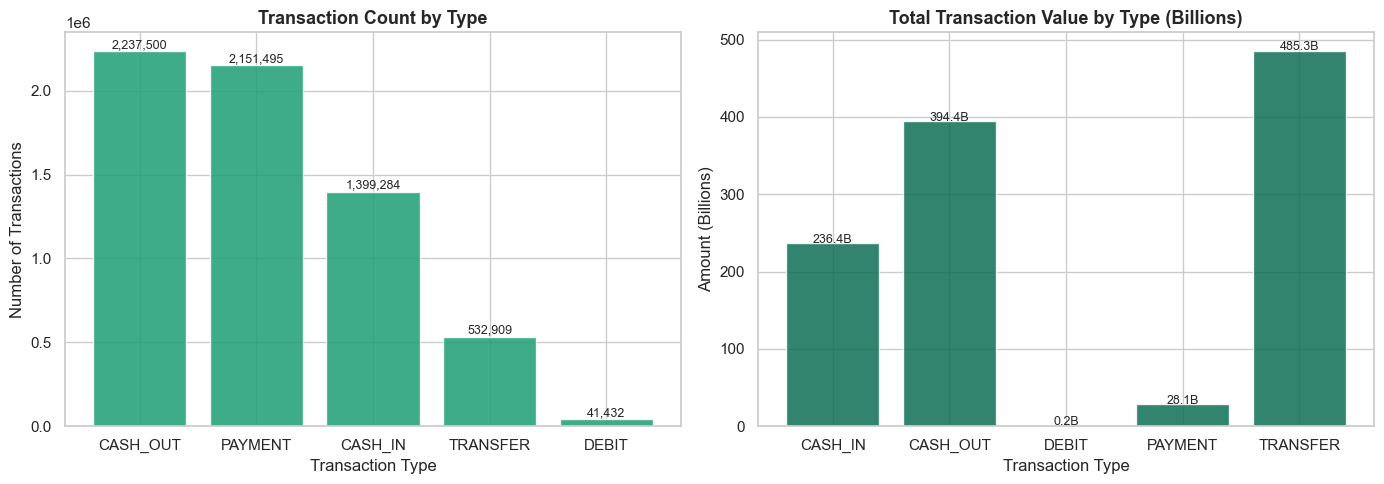

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count by type
type_counts = df['type'].value_counts()
axes[0].bar(type_counts.index, type_counts.values, color='#1D9E75', alpha=0.85)
axes[0].set_title('Transaction Count by Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_xlabel('Transaction Type')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 20000, f'{v:,}', ha='center', fontsize=9)

# Total value by type
type_value = df.groupby('type')['amount'].sum() / 1e9
axes[1].bar(type_value.index, type_value.values, color='#0F6E56', alpha=0.85)
axes[1].set_title('Total Transaction Value by Type (Billions)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Amount (Billions)')
axes[1].set_xlabel('Transaction Type')
for i, v in enumerate(type_value.values):
    axes[1].text(i, v + 1, f'{v:.1f}B', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('reports/01_transaction_types.png', dpi=150, bbox_inches='tight')
plt.show()

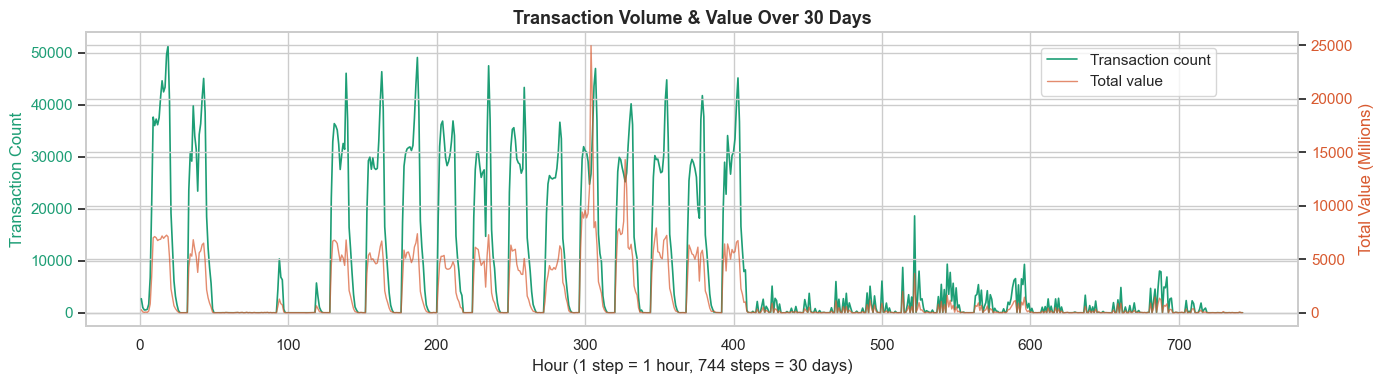

In [13]:
hourly = df.groupby('step').agg(
    count=('amount', 'count'),
    total_value=('amount', 'sum')
).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 4))

ax1.plot(hourly['step'], hourly['count'], color='#1D9E75', linewidth=1.2, label='Transaction count')
ax1.set_xlabel('Hour (1 step = 1 hour, 744 steps = 30 days)')
ax1.set_ylabel('Transaction Count', color='#1D9E75')
ax1.tick_params(axis='y', labelcolor='#1D9E75')

ax2 = ax1.twinx()
ax2.plot(hourly['step'], hourly['total_value']/1e6, color='#D85A30', linewidth=1, alpha=0.7, label='Total value')
ax2.set_ylabel('Total Value (Millions)', color='#D85A30')
ax2.tick_params(axis='y', labelcolor='#D85A30')

plt.title('Transaction Volume & Value Over 30 Days', fontsize=13, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.88, 0.88))
plt.tight_layout()
plt.savefig('reports/02_volume_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

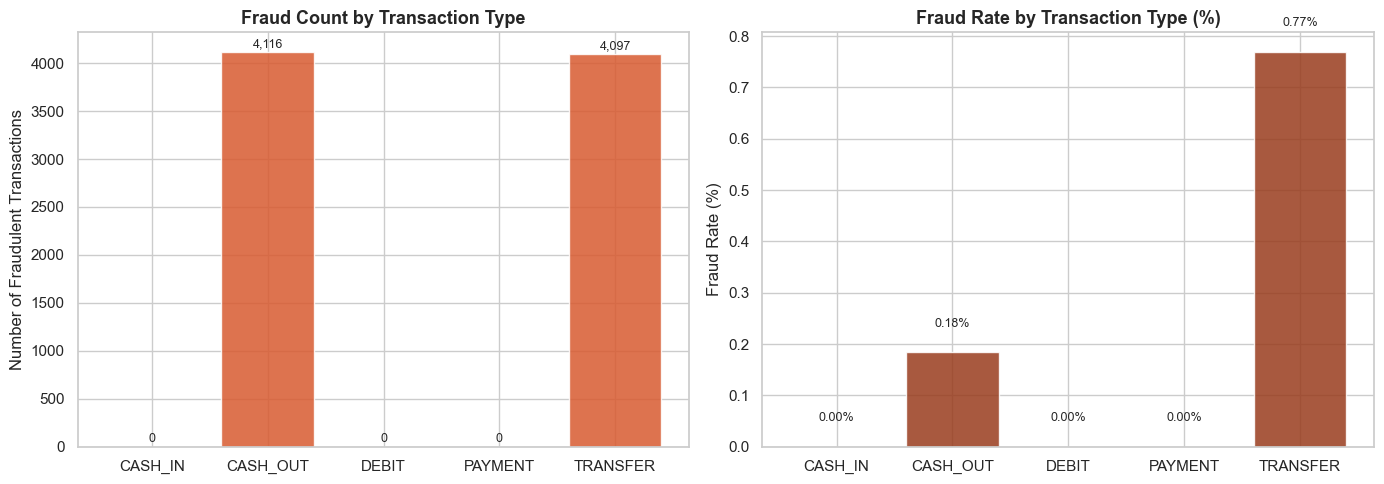


Fraud only occurs in these types:
       type  fraud_count  fraud_rate
1  CASH_OUT         4116    0.001840
4  TRANSFER         4097    0.007688


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fraud by transaction type
fraud_by_type = df.groupby('type')['isFraud'].agg(['sum', 'mean']).reset_index()
fraud_by_type.columns = ['type', 'fraud_count', 'fraud_rate']

axes[0].bar(fraud_by_type['type'], fraud_by_type['fraud_count'], color='#D85A30', alpha=0.85)
axes[0].set_title('Fraud Count by Transaction Type', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Fraudulent Transactions')
for i, v in enumerate(fraud_by_type['fraud_count']):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# Fraud rate by type
axes[1].bar(fraud_by_type['type'], fraud_by_type['fraud_rate']*100, color='#993C1D', alpha=0.85)
axes[1].set_title('Fraud Rate by Transaction Type (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(fraud_by_type['fraud_rate']*100):
    axes[1].text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('reports/03_fraud_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFraud only occurs in these types:")
print(fraud_by_type[fraud_by_type['fraud_count'] > 0][['type','fraud_count','fraud_rate']])